### DECISION TREE CLASSIFIER
In this assignment we will try to predict whether a vehicle is deemed accpetable or unacceptable depending upon factors such as maintenance, number of doors, safety, etc.

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define constants
COUNT_THRESHOLD = 5  # Count threshold for labeling a node as a leaf
MAX_DEPTH = 3  # Maximum depth for the decision tree

In [3]:
# Function 1: Calculate Gini Impurity
def calculate_gini(data):
  if len(data) == 0:
    return 0.0

  label_counts = {}
  for row in data:
    label = row[-1]
    if label not in label_counts:
      label_counts[label] = 0
    label_counts[label] += 1

  total = len(data)
  gini = 1.0
  for count in label_counts.values():
    prob = count / total
    gini -= prob**2

  return gini


In [4]:
# Function 2: Split dataset by an attribute
def split_data(data, attribute_index, value):
  return [row for row in data if row[attribute_index] == value]

In [6]:
# Function 3: Calculate Gini Gain
def gini_gain(data, attribute_index):
    if len(data) == 0:
        return 0.0

    parent_gini = calculate_gini(data)
    total_len = len(data)

    unique_values = set(row[attribute_index] for row in data)

    weighted_gini = 0.0
    for value in unique_values:
        subset = split_data(data, attribute_index, value)
        weight = len(subset) / total_len
        weighted_gini += weight * calculate_gini(subset)

    gain = parent_gini - weighted_gini
    return gain



In [7]:
# Function 4: Build the Decision Tree
from collections import Counter

def majority_label(data):
    labels = [row[-1] for row in data]
    return Counter(labels).most_common(1)[0][0]

def build_tree(data, attributes, depth=0):
    # Stopping Condition 1: All examples belong to one class (pure node)
    if calculate_gini(data) == 0:
        return data[0][-1]

    # Stopping Condition 2: No attributes left
    if len(attributes) == 0:
        return majority_label(data)

    # Stopping Condition 3: Max depth reached or not enough samples
    if depth >= MAX_DEPTH or len(data) < COUNT_THRESHOLD:
        return majority_label(data)

    #Best attribute for splitting
    best_gain = 0
    best_attr = None
    for attr in attributes:
        gain = gini_gain(data, attr)
        if gain > best_gain:
            best_gain = gain
            best_attr = attr
    if best_attr is None:
        return majority_label(data)

    tree = {best_attr: {}}

    unique_values = set(row[best_attr] for row in data)
    new_attributes = [attr for attr in attributes if attr != best_attr]

    for value in unique_values:
        subset = split_data(data, best_attr, value)
        if not subset:
            tree[best_attr][value] = majority_label(data)
        else:
            tree[best_attr][value] = build_tree(subset, new_attributes, depth + 1)

    return tree


In [8]:
# Function 5: Predict a Single Instance
def predict(tree, instance):
    while isinstance(tree, dict):
        attribute_index = next(iter(tree))
        attribute_value = instance.get(attribute_index)
        if attribute_value in tree[attribute_index]:
            tree = tree[attribute_index][attribute_value]
        else:
            return None

    return tree


In [10]:
# Load the dataset from the CSV file
df = pd.read_csv("/content/car_evaluation.csv")

# Define a mapping for the categorical values to numerical values
value_mappings = {
    'buying': {'vhigh': 3, 'high': 2, 'med': 1, 'low': 0},
    'maint': {'vhigh': 3, 'high': 2, 'med': 1, 'low': 0},
    'doors': {'2': 0, '3': 1, '4': 2, '5more': 3},
    'persons': {'2': 0, '4': 1, 'more': 2},
    'lug_boot': {'small': 0, 'med': 1, 'big': 2},
    'safety': {'low': 0, 'med': 1, 'high': 2}
}

# Apply the mappings to the dataset
for column, mapping in value_mappings.items():
    df[column] = df[column].map(mapping)

# Extract the features and target
X = df.drop(columns=['class'])  # Drop the target column
y = df['class'].map({'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3})  # Map target to numerical values

# Convert DataFrame to list for the decision tree
data = df.values.tolist()
attributes = list(range(len(X.columns)))  # Indexes of the attributes (buying, maint, etc.)
attribute_names = list(X.columns)  # Get the actual attribute names


In [11]:
# Build the decision tree
tree = build_tree(data, attributes)
print("Decision Tree:", tree)

Decision Tree: {5: {0: 'unacc', 1: {3: {0: 'unacc', 1: {0: {0: 'acc', 1: 'acc', 2: 'unacc', 3: 'unacc'}}, 2: {4: {0: 'unacc', 1: 'acc', 2: 'acc'}}}}, 2: {3: {0: 'unacc', 1: {0: {0: 'acc', 1: 'acc', 2: 'acc', 3: 'unacc'}}, 2: {0: {0: 'vgood', 1: 'acc', 2: 'acc', 3: 'unacc'}}}}}}


<Figure size 1400x800 with 0 Axes>

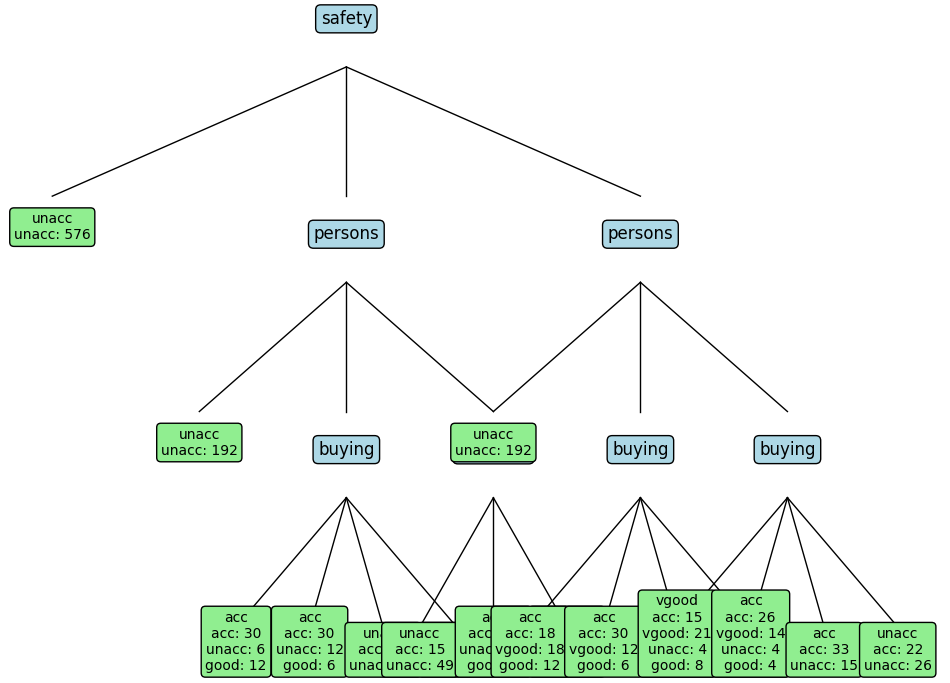

In [24]:

# Visualize the decision tree
def plot_tree(tree, depth=0, x_offset=0.5, y_offset=1.0, x_gap=0.25, ax=None, data=None, attribute_names=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.axis('off')  # Turn off the axes

    # If the tree is a leaf node, plot the label and counts
    if not isinstance(tree, dict):
      if data is not None:
        label_counts = {label: sum(1 for row in data if row[-1] == label) for label in set(row[-1] for row in data)}
        label_text = f"{tree}\n" + "\n".join([f"{label}: {count}" for label, count in label_counts.items()])
      else:
        label_text = str(tree)

      ax.text(x_offset, y_offset, label_text, fontsize=10, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", edgecolor="black"))
      return
    # Get the current decision attribute name
    root = list(tree.keys())[0]
    attribute_name = attribute_names[root]  # Map the index to the attribute name
    ax.text(x_offset, y_offset, f"{attribute_name}", fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", edgecolor="black"))

    # Recursively plot child nodes
    num_children = len(tree[root])
    for i, (value, subtree) in enumerate(tree[root].items()):
        child_x = x_offset + (i - (num_children - 1) / 2) * x_gap  # Calculate child x position
        child_y = y_offset - 0.1  # Shift vertically for the child nodes

        # Draw a line to the child node
        ax.plot([x_offset, child_x], [y_offset - 0.02, child_y + 0.02], 'k-', lw=1)

        # Recursively call plot_tree for the child node, passing the subset of data that corresponds to the child
        subset = split_data(data, root, value)  # Get the subset of data for this child
        plot_tree(subtree, depth + 1, child_x, child_y, x_gap / 2, ax=ax, data=subset, attribute_names=attribute_names)

    if depth == 0:  # Show the plot only at the top level
        plt.show()



# Visualize the decision tree
plt.figure(figsize=(14, 8))
plot_tree(tree, data=data, attribute_names=attribute_names)

In [25]:
# Test prediction
test_instance = {0: 1, 1: 2}  # Middle-aged with High income
prediction = predict(tree, test_instance)
print("\nPrediction for test instance:", "Yes" if prediction == 1 else "No")


Prediction for test instance: No
